In [ ]:
# ============================================================
# 1. INSTALL LIBRARIES
# ============================================================

!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib pandas pyarrow torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import evaluate


In [ ]:
# ============================================================
# 3. LOAD REAL DATASET
# ============================================================
# Upload:
# train-00000-of-00001.parquet
# from Kaggle dataset

df = pd.read_parquet("train-00000-of-00001.parquet")

print("DATASET PREVIEW:")
print(df.head())

print("\nCOLUMNS:")
print(df.columns)

df = df[["text", "label"]].dropna()

# Smaller subset for faster training
df = df.sample(5000, random_state=42)




DATASET PREVIEW:
                                                text  label
0  i feel awful about it too because it s my job ...      0
1                              im alone i feel awful      0
2  ive probably mentioned this before but i reall...      1
3           i was feeling a little low few days back      0
4  i beleive that i am much more sensitive to oth...      2

COLUMNS:
Index(['text', 'label'], dtype='object')


In [ ]:
# ============================================================
# 4. TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


In [ ]:
# ============================================================
# 5. LOAD ACCURACY METRIC
# ============================================================

accuracy_metric = evaluate.load("accuracy")




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# ============================================================
# 6. COMPUTE METRICS
# ============================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )



In [ ]:
# ============================================================
# 7. TRANSFORMER MODELS
# ============================================================

model_names = {
    "RoBERTa": "roberta-base",
    "DistilBERT": "distilbert-base-uncased",
    "ELECTRA": "google/electra-base-discriminator"
}

In [ ]:
# ============================================================
# 8. TRAIN AND EVALUATE ALL MODELS
# ============================================================

results = {}

training_losses = {}

trained_models = {}

tokenizers = {}

# Get device for model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


for model_label, model_path in model_names.items():

    print("\n" + "="*60)
    print(f"TRAINING {model_label}")
    print("="*60)



    # --------------------------------------------------------
    # TOKENIZER
    # --------------------------------------------------------

    tokenizer = AutoTokenizer.from_pretrained(
        model_path
    )

    tokenizers[model_label] = tokenizer



    # --------------------------------------------------------
    # TOKENIZATION FUNCTION
    # --------------------------------------------------------

    def tokenize(batch):

        return tokenizer(
            batch["text"],
            padding="max_length",
            truncation=True,
            max_length=128
        )



    tokenized_train = train_dataset.map(
        tokenize,
        batched=True
    )

    tokenized_test = test_dataset.map(
        tokenize,
        batched=True
    )



    # --------------------------------------------------------
    # LOAD MODEL
    # --------------------------------------------------------

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=6
    ).to(device)



    # --------------------------------------------------------
    # TRAINING ARGUMENTS
    # --------------------------------------------------------

    training_args = TrainingArguments(
        output_dir=f"./{model_label}_results",

        eval_strategy="epoch",

        save_strategy="no",

        learning_rate=2e-5,

        per_device_train_batch_size=8,

        per_device_eval_batch_size=8,

        num_train_epochs=3,

        weight_decay=0.01,

        logging_steps=50,

        report_to="none"
    )



    # --------------------------------------------------------
    # TRAINER
    # --------------------------------------------------------

    trainer = Trainer(
        model=model,

        args=training_args,

        train_dataset=tokenized_train,

        eval_dataset=tokenized_test,

        compute_metrics=compute_metrics
    )



    # --------------------------------------------------------
    # TRAIN MODEL
    # --------------------------------------------------------

    trainer.train()

    # --------------------------------------------------------
    # STORE TRAINING HISTORY
    # --------------------------------------------------------

    history = trainer.state.log_history

    train_loss = []
    eval_loss = []
    eval_accuracy = []
    epochs = []

    for log in history:

        if "loss" in log and "epoch" in log:
            train_loss.append(log["loss"])

        if "eval_loss" in log:
            eval_loss.append(log["eval_loss"])

        if "eval_accuracy" in log:
            eval_accuracy.append(log["eval_accuracy"])
            epochs.append(log["epoch"])

    # Save histories
    training_losses[model_label] = {
        "train_loss": train_loss,
        "eval_loss": eval_loss,
        "eval_accuracy": eval_accuracy,
        "epochs": epochs
    }



    # --------------------------------------------------------
    # EVALUATE MODEL
    # --------------------------------------------------------

    eval_result = trainer.evaluate()

    accuracy = eval_result["eval_accuracy"]

    results[model_label] = accuracy

    trained_models[model_label] = trainer

    print(f"\nAccuracy: {accuracy:.4f}")



TRAINING RoBERTa


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,0.995392,0.961046,0.655000
2,0.527592,0.546817,0.847000
3,0.344988,0.481542,0.867000



Accuracy: 0.8670


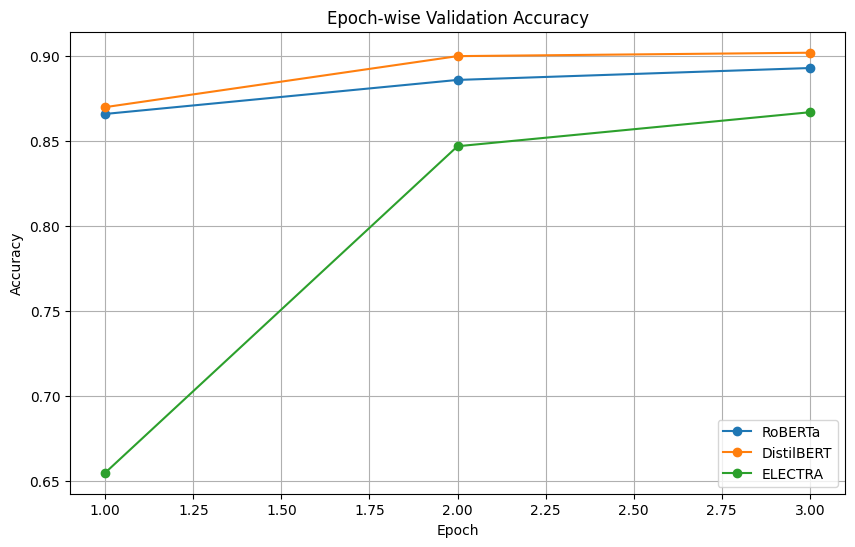

In [ ]:
# ============================================================
# 9.EPOCH-WISE ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(10,6))

for model_name, history in training_losses.items():

    plt.plot(
        history["epochs"],
        history["eval_accuracy"],
        marker='o',
        label=model_name
    )

plt.title("Epoch-wise Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

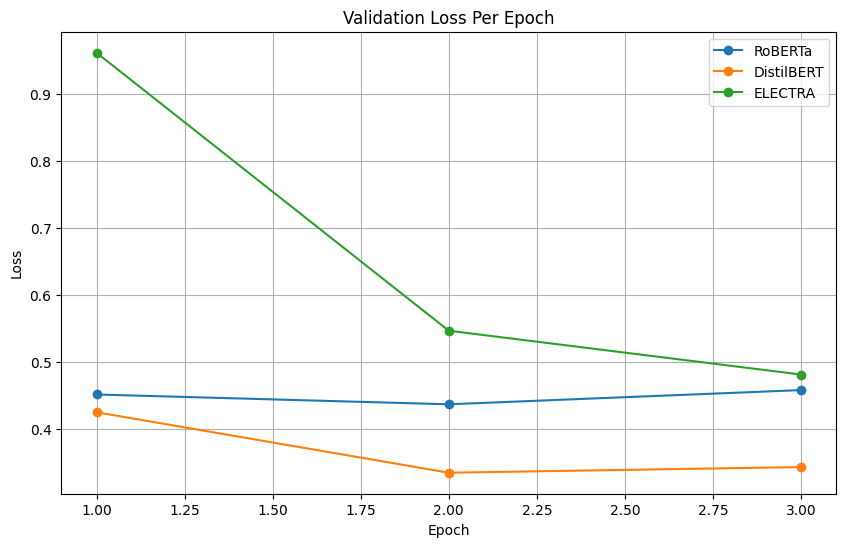

In [ ]:
# ============================================================
# 10. LOSS PER EPOCH GRAPH
# ============================================================

plt.figure(figsize=(10,6))

for model_name, history in training_losses.items():

    plt.plot(
        history["epochs"],
        history["eval_loss"],
        marker='o',
        label=model_name
    )

plt.title("Validation Loss Per Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

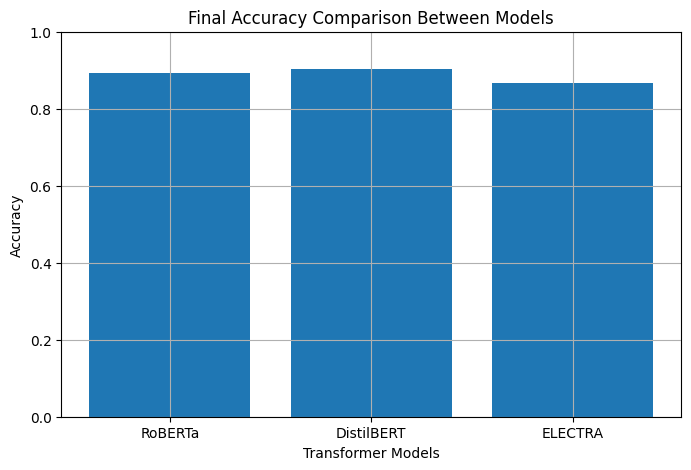

In [ ]:
# ============================================================
# 11.MODEL COMPARISON ACCURACY GRAPH
# ============================================================

model_accuracies = {}

for model_name, history in training_losses.items():

    final_accuracy = history["eval_accuracy"][-1]

    model_accuracies[model_name] = final_accuracy



plt.figure(figsize=(8,5))

plt.bar(
    list(model_accuracies.keys()),
    list(model_accuracies.values())
)

plt.title("Final Accuracy Comparison Between Models")

plt.xlabel("Transformer Models")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.grid(True)

plt.show()

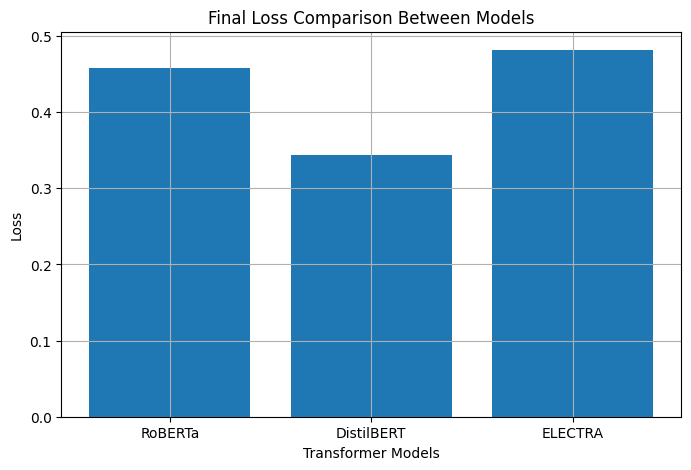

In [ ]:
# ============================================================
# 12.MODEL COMPARISON LOSS GRAPH
# ============================================================

model_losses = {}

for model_name, history in training_losses.items():

    final_loss = history["eval_loss"][-1]

    model_losses[model_name] = final_loss



plt.figure(figsize=(8,5))

plt.bar(
    list(model_losses.keys()),
    list(model_losses.values())
)

plt.title("Final Loss Comparison Between Models")

plt.xlabel("Transformer Models")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# 13. BEST MODEL SELECTION
# ============================================================

best_model_name = max(results, key=results.get)

best_trainer = trained_models[best_model_name]

best_tokenizer = tokenizers[best_model_name]

print("\nBEST MODEL:")
print(best_model_name)

print("\nBEST ACCURACY:")
print(round(results[best_model_name], 4))



BEST MODEL:
DistilBERT

BEST ACCURACY:
0.902


In [ ]:
# ============================================================
# 14. EMOTION LABEL MAP
# ============================================================

emotion_labels = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}



In [ ]:
# ============================================================
# 15. EMOTION SCORE MAP
# ============================================================

emotion_scores = {
    "sadness": -1.0,
    "joy": 1.0,
    "love": 0.9,
    "anger": -1.0,
    "fear": -0.7,
    "surprise": 0.4
}


In [ ]:
# ============================================================
# 16. WEEKLY LOG SEGMENTATION
# ============================================================
# Every 3 sentences = pseudo-week

def create_weekly_logs(sentences, week_size=3):

    weeks = []

    for i in range(0, len(sentences), week_size):

        weeks.append(
            sentences[i:i+week_size]
        )

    return weeks



In [ ]:
# ============================================================
# 17. EMOTION PREDICTION
# ============================================================

def predict_emotion(sentence):

    inputs = best_tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move inputs to the same device as the model
    inputs = {k: v.to(best_trainer.model.device) for k, v in inputs.items()}

    with torch.no_grad():

        outputs = best_trainer.model(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    emotion = emotion_labels[prediction]

    return emotion


In [ ]:
# ============================================================
# 18. TEMPORAL FEATURE EXTRACTION
# ============================================================

def extract_temporal_features(values):

    trend = values[-1] - values[0]

    volatility = np.std(values)

    average = np.mean(values)

    minimum = np.min(values)

    maximum = np.max(values)

    return {
        "trend": trend,
        "volatility": volatility,
        "average": average,
        "minimum": minimum,
        "maximum": maximum
    }

In [ ]:
# ============================================================
# 19. LSTM MODEL
# ============================================================

class MentalStateLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32,1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = self.fc(out[:, -1, :])

        return out




In [ ]:
# ============================================================
# 20. TRAIN LSTM
# ============================================================

def train_lstm(sequence):

    if len(sequence) < 2:
        return None, []

    model = MentalStateLSTM()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    loss_function = nn.MSELoss()

    X = torch.tensor(
        sequence[:-1],
        dtype=torch.float32
    ).view(1,-1,1)

    y = torch.tensor(
        [sequence[-1]],
        dtype=torch.float32
    )

    losses = []

    for epoch in range(30):

        prediction = model(X)

        loss = loss_function(
            prediction.view(-1),
            y.view(-1)
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return model, losses




In [ ]:
# ============================================================
# 21. PLOT EMOTION TREND
# ============================================================

def plot_emotion_trend(values):

    plt.figure(figsize=(10,5))

    plt.plot(
        range(1, len(values)+1),
        values,
        marker='o'
    )

    plt.title("Emotion Trend Over Time")

    plt.xlabel("Time Sequence")

    plt.ylabel("Emotion Score")

    plt.grid(True)

    plt.show()



In [ ]:
# ============================================================
# 22. PLOT LSTM LOSS
# ============================================================

def plot_lstm_loss(losses):

    plt.figure(figsize=(8,5))

    plt.plot(losses)

    plt.title("LSTM Training Loss")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.grid(True)

    plt.show()



In [ ]:
# ============================================================
# 23. FINAL RISK CALCULATION
# ============================================================

def calculate_risk(values):

    avg_emotion = np.mean(values)

    trend = values[-1] - values[0]

    volatility = np.std(values)

    risk_score = (
        ((1 - avg_emotion) * 0.4)
        + (volatility * 0.3)
        + (max(0, -trend) * 0.3)
    )

    risk_score = max(
        0,
        min(risk_score, 1)
    )

    if risk_score > 0.7:
        level = "HIGH"

    elif risk_score > 0.4:
        level = "MEDIUM"

    else:
        level = "LOW"

    return risk_score, level




In [ ]:
# ============================================================
# 24. MAIN ANALYSIS FUNCTION
# ============================================================

def analyze(text):

    sentences = [
        s.strip()
        for s in text.split("\n")
        if s.strip()
    ]

    if len(sentences) < 3:

        print("Please enter at least 3 sentences.")

        return



    print("\n" + "="*60)
    print("AI MENTAL STATE MODELING")
    print("="*60)



    # --------------------------------------------------------
    # WEEKLY LOGS
    # --------------------------------------------------------

    weeks = create_weekly_logs(sentences)

    print("\nWEEKLY LOGS:")

    for i, week in enumerate(weeks):

        print(f"\nWeek {i+1}")

        for sentence in week:
            print("-", sentence)



    # --------------------------------------------------------
    # EMOTION PREDICTION
    # --------------------------------------------------------

    emotions = []

    for sentence in sentences:

        emotion = predict_emotion(sentence)

        emotions.append(emotion)



    print("\n" + "-"*50)
    print("EMOTION ANALYSIS")
    print("-"*50)

    for i, emotion in enumerate(emotions):

        print(f"Sentence {i+1}: {emotion}")



    # --------------------------------------------------------
    # EMOTION SCORES
    # --------------------------------------------------------

    values = [
        emotion_scores[e]
        for e in emotions
    ]



    # --------------------------------------------------------
    # TEMPORAL FEATURES
    # --------------------------------------------------------

    temporal = extract_temporal_features(values)

    print("\n" + "-"*50)
    print("TEMPORAL ANALYSIS")
    print("-"*50)

    for k, v in temporal.items():

        print(f"{k}: {round(float(v),3)}")



    # --------------------------------------------------------
    # EMOTION TREND GRAPH
    # --------------------------------------------------------

    plot_emotion_trend(values)



    # --------------------------------------------------------
    # LSTM MODELING
    # --------------------------------------------------------

    lstm_model, losses = train_lstm(values)

    plot_lstm_loss(losses)



    # --------------------------------------------------------
    # FINAL RISK
    # --------------------------------------------------------

    risk_score, risk_level = calculate_risk(values)

    print("\n" + "-"*50)
    print("FINAL RISK ASSESSMENT")
    print("-"*50)

    print("Risk Score:",
          round(float(risk_score),3))

    print("Risk Level:",
          risk_level)

    print("="*60)




In [ ]:
# ============================================================
# 25. USER INPUT
# ============================================================

print("\nEnter weekly emotional logs.")
print("Press ENTER twice to stop.\n")

lines = []

while True:

    x = input()

    if x == "":
        break

    lines.append(x)

input_text = "\n".join(lines)



analyze(input_text)